In [2]:
# --- repo bootstrap: make `panelclv` importable and relative data paths resolve ---
import os, sys
from pathlib import Path
_root = Path.cwd().resolve()
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
os.chdir(_root)                                 # so "Datasets/..." resolve from repo root
_src = _root / 'src'
if _src.exists() and str(_src) not in sys.path:  # fallback if panelclv isn't pip-installed
    sys.path.insert(0, str(_src))
# ---------------------------------------------------------------------------------

%reload_ext autoreload
%autoreload 2

In Terminal all the time
cd ~/Desktop/Thesis
source venvs/thesis_rocm/bin/activate

cd /home/virthian/Desktop/Thesis/Package/my_package/autoseqmodels
pip install -e .

In [3]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import json
from pathlib import Path

# ---------------------------------------------------------------------------
# Third-party
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------------------------
# This project (installed via `pip install -e .`, so no manual path setup).
# Models/__init__.py is the public API.
# ---------------------------------------------------------------------------
from panelclv.data_preparation import dynamic_panel_dataset
from panelclv.models import (
    MultinomialLSTMModel,  # softmax-over-counts LSTM (classifier head)
    compute_class_weights,  # class weights for weighted_ce / focal
    InferenceMultinomialLSTMModel,  # same backbone, sampling head
    mc_forecast,  # Valendin-style autoregressive holdout rollout
    mc_compute_metrics,  # RMSE / bias% / aggregate-MAPE
)
from panelclv.training import (
    fit_model,  # shared training loop (CE / weighted_ce / focal / emd)
)
from panelclv.tuning import (
    run_optuna_study,  # hyper-parameter + covariate search
)
from panelclv.evaluation import (
    weekly_actuals,
    weekly_aggregate_predictions,
    plot_weekly_aggregated,
    metrics_table,
    alignment_check,
    save_predictions_to_csv,
)
from panelclv.experiments import (
    make_data_builder,  # builds the Optuna data_builder closure
    build_inference_from_trial,  # rebuilds the winning model + loads its checkpoint
    refit_best_trial,  # warm-start retrain the winner on the full calibration window
)

# Data Loading


### Panels configuration

In [4]:
from panelclv.configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg_2yTrain_1yPred_NoCov = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    # Temporal validation window: the last year of calibration (2000) is held out
    # for early stopping / model selection -- a TIME window over all customers,
    # never trained on. ~52 weeks, matching the holdout length.
    validation_start="2000-01-01",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "week"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_week_sin_cos": True},
    #ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # week_sin / week_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=(),
    static=(),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto"},
)


In [5]:
from panelclv.configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    # Temporal validation window: the last year of calibration (2000) is held out
    # for early stopping / model selection -- a TIME window over all customers,
    # never trained on. ~52 weeks, matching the holdout length.
    validation_start="2000-01-01",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "month"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_month_sin_cos": True},
    #ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # month_sin / month_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=("year_idx", "high.season"),
    static=("Gender", "Income"),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto", "Gender": "auto", "Income": "auto"},
)


<string>:23: UserWarning: time feature 'add_month_sin_cos' is not compatible with frequency 'weekly'; ignoring it.


In [6]:

panel     = pd.read_csv(csv_path)
data_full = dynamic_panel_dataset.prepare_dataset(panel, cfg_2yTrain_1yPred_NoCov)


N=829 T_CAL=104 T_HOLD=52 F=3
validation_start=2000-01-01 -> val_start_idx=52 (train periods 0..51, validation periods 52..103, V=52)
seq_cols   = ['Transactions', 'week_sin', 'week_cos']
target_col = 'Transactions' at index 0
calibration (829, 104, 3) | samples (829, 103, 3) | targets (829, 103, 1) | holdout (829, 52, 3)
embedded_cols = {'Transactions': 7}


## LSTM training & hyperparameter search

### LSTM with Optuna

### Loss trials

In [7]:
LOSS_TYPE     = "cross_entropy"            # 'cross_entropy' | 'weighted_ce' | 'focal' | 'emd'
CONFIG_NAME =	"cfg_2yTrain_1yPred_NoCov"

In [8]:
# ---- 6. data_builder for Optuna -----------------------------------------
# `make_data_builder` returns the closure run_optuna_study calls each trial: it
# slices data_full to the trial's feature subset and builds the temporal train/val
# DataLoaders (the split is data_full["val_start_idx"], shared by every trial).
data_builder = make_data_builder(data_full)


## Optuna optimization cross entropy

In [9]:
# ---- 7. Run the LSTM Optuna study ---------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"lstm_{LOSS_TYPE}_{CONFIG_NAME}"            # one study per loss → no schema collisions

lstm_study = run_optuna_study(
    model_type="lstm",
    data_builder=data_builder,
    data_info={
        "n_epochs":       {100},
        "patience":       {5,7,9},
        "batch_size": {64, 128, 256},
        
								# Hyperparameters
        "learning_rate": (1e-4, 1e-2, "log"),  # new line
        "embedding_dim":{64, 128,256}, # Dimension of each feature vector in the lstm (if context is used, context_sum + embd_target)-> 2*embedding_dim. (=lstm_input_size))
        "lstm_hidden_size":{32, 64, 128}, #LSTM	memory cell size (hHIDDEN_SIZE) (=lstm_hidden_size)
        "dense_units":{32, 64, 128}, # Dimension of the dense layer before the output layer
        "dropout":{0.0, 0.2, 0.4},

        # Parameters for checkpoint naming and early stopping; not hyperparameters, so outside the search space.								
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        #"class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("month_sin", "month_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=100,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/Study.db", #new line
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-06-20 16:39:53,561] A new study created in RDB with name: lstm_cross_entropy_cfg_2yTrain_1yPred_NoCov_20260620_1639
[I 2026-06-20 16:39:57,806] Trial 0 finished with value: 0.08998349495232105 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 32, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.004622589001020831, 'weight_decay': 7.068974950624607e-06, 'batch_size': 256, 'n_epochs': 100, 'patience': 5}. Best is trial 0 with value: 0.08998349495232105.
[I 2026-06-20 16:40:02,502] Trial 1 finished with value: 0.09412898323856868 and parameters: {'embedding_dim': 64, 'lstm_hidden_size': 128, 'dense_units': 128, 'dropout': 0.2, 'learning_rate': 0.00013492834268013249, 'weight_decay': 0.006245139574743076, 'batch_size': 64, 'n_epochs': 100, 'patience': 7}. Best is trial 0 with value: 0.08998349495232105.
[I 2026-06-20 16:40:13,463] Trial 2 finished with value: 0.08989524096250534 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 32, 'dense_units': 128, 'dropou

best trial   : 70
best val loss: 0.08820360340178013
best params  : {'embedding_dim': 128, 'lstm_hidden_size': 32, 'dense_units': 128, 'dropout': 0.0, 'learning_rate': 0.0013236189125830139, 'weight_decay': 0.000297717238625632, 'batch_size': 256, 'n_epochs': 100, 'patience': 9}
checkpoint   : checkpoints/lstm_optuna/lstm_cross_entropy_cfg_2yTrain_1yPred_NoCov_20260620_1639/lstm_trial_70.pth


In [10]:
# ---- 8. Rebuild the LSTM with the Optuna-selected arch + load weights ----
# `build_inference_from_trial` reads the best trial's architecture + checkpoint,
# slices data_full to that trial's feature subset, rebuilds the matching inference
# model (always samples), and loads the weights. It returns BOTH the model and the
# sliced `data_best` -- feed data_best (not data_full) to the forecaster so the
# feature columns match the trained weights.
inference_model, data_best = build_inference_from_trial(lstm_study, data_full, "lstm")

In [11]:
# ---- 8b. (Optional) Final retrain on the FULL calibration window ----------
# Valendin et al. (the paper) warm-start the selected model and fine-tune it for a
# few BIG-BATCH epochs on the FULL calibration window -- the temporal validation tail
# INCLUDED -- so the weights also LEARN the most recent periods, not just condition on
# them at forecast time (warm-up always sees the full calibration regardless). This
# rebinds inference_model / data_best with the refit weights.
#
# Tune the retrain here:
REFIT_ON_FULL_CALIBRATION = True   # False -> forecast with the tuning checkpoint as-is
                                   #          (the published rfm2lstm GitHub behaviour)
REFIT_BATCH_SIZE = 512             # the paper's "big batch"; raise/lower to taste
REFIT_N_EPOCHS   = None            # None -> a few epochs (default 5); set an int
                                   #         for a fixed number of epochs

if REFIT_ON_FULL_CALIBRATION:
    inference_model, data_best = refit_best_trial(
        lstm_study, data_full, "lstm",
        n_epochs=REFIT_N_EPOCHS,
        batch_size=REFIT_BATCH_SIZE,
        device=device,
        checkpoint_dir="./checkpoints/lstm_optuna",
    )


[refit] Epoch   1/5 | train_loss=0.1502 train_acc=0.9756
[refit] Epoch   2/5 | train_loss=0.1484 train_acc=0.9756
[refit] Epoch   3/5 | train_loss=0.1473 train_acc=0.9756
[refit] Epoch   4/5 | train_loss=0.1462 train_acc=0.9756
[refit] Epoch   5/5 | train_loss=0.1440 train_acc=0.9756


In [12]:
# ---- 9. Valendin-style autoregressive MC forecast ------------------------
# mc_forecast warms the model on each customer's full calibration window, then
# steps through the holdout one period at a time: at every step it SAMPLES a
# count class from the softmax and feeds that sample back as the next input
# (true holdout targets are never seen). Averaging n_simulations such paths
# gives the expected count per customer per week. AR features are recomputed
# from the sampled history inside the rollout, so nothing leaks.
N_SIMULATIONS = 200          # more paths -> smoother mean, more compute
MC_SEED = 42                 # fixes the sampling so the forecast is reproducible
forecast = mc_forecast(
    inference_model,
    data_best,               # the SLICED dict (matches the trained feature set)
    n_simulations=N_SIMULATIONS,
    device=device,
    seed=MC_SEED,
)

# Guard against a stale (not-re-run) cell silently reporting an old count.
assert forecast["simulations"].shape[0] == forecast["n_simulations"] == N_SIMULATIONS

# simulations = the raw sampled paths; prediction_mean = their mean (the point
# forecast); actual = the true holdout counts, pulled from data_best["holdout"].
print("simulations shape:", forecast["simulations"].shape)        # (S, N, T_HOLD)
print("prediction mean  :", forecast["prediction_mean"].shape)    # (N, T_HOLD)
print("actual (real)    :", forecast["actual"].shape)             # (N, T_HOLD)


simulations shape: (200, 829, 52)
prediction mean  : (829, 52)
actual (real)    : (829, 52)


In [13]:
# ---- 10. Score + sanity check -------------------------------------------
# mc_compute_metrics works on the per-customer (N, T_HOLD) arrays and returns
# the thesis headline metrics: RMSE, aggregate bias %, and aggregate-style MAPE.
metrics = mc_compute_metrics(forecast["actual"], forecast["prediction_mean"])
print(metrics)

# Eyeball the weekly aggregate (sum over customers) for the first 20 weeks: a
# quick read on whether the forecast tracks the level and the seasonal shape
# before drawing the full plot. Persistent pred > actual here = positive bias.
agg_pred   = forecast["prediction_mean"].sum(axis=0)              # (T_HOLD,)
agg_actual = forecast["actual"].sum(axis=0)
for i in range(min(20, len(agg_pred))):
    print(f"  week {i:>2}  pred={agg_pred[i]:6.1f}  actual={agg_actual[i]:6.1f}")


{'rmse': 0.37667891541047943, 'bias_percent': 17.701772141734413, 'mape_aggregate_style': 52.01056580692174}
  week  0  pred=  51.2  actual=  46.0
  week  1  pred=  52.3  actual=  54.0
  week  2  pred=  55.0  actual=  64.0
  week  3  pred=  58.7  actual=  42.0
  week  4  pred=  59.1  actual=  40.0
  week  5  pred=  61.6  actual=  51.0
  week  6  pred=  61.0  actual=  40.0
  week  7  pred=  58.1  actual=  37.0
  week  8  pred=  56.0  actual=  15.0
  week  9  pred=  53.8  actual=   8.0
  week 10  pred=  54.0  actual=  16.0
  week 11  pred=  50.6  actual=  23.0
  week 12  pred=  47.0  actual=  13.0
  week 13  pred=  43.9  actual=   7.0
  week 14  pred=  39.9  actual=  23.0
  week 15  pred=  35.0  actual=  34.0
  week 16  pred=  32.9  actual=   6.0
  week 17  pred=  30.1  actual=  24.0
  week 18  pred=  27.7  actual=  12.0
  week 19  pred=  25.4  actual=   6.0


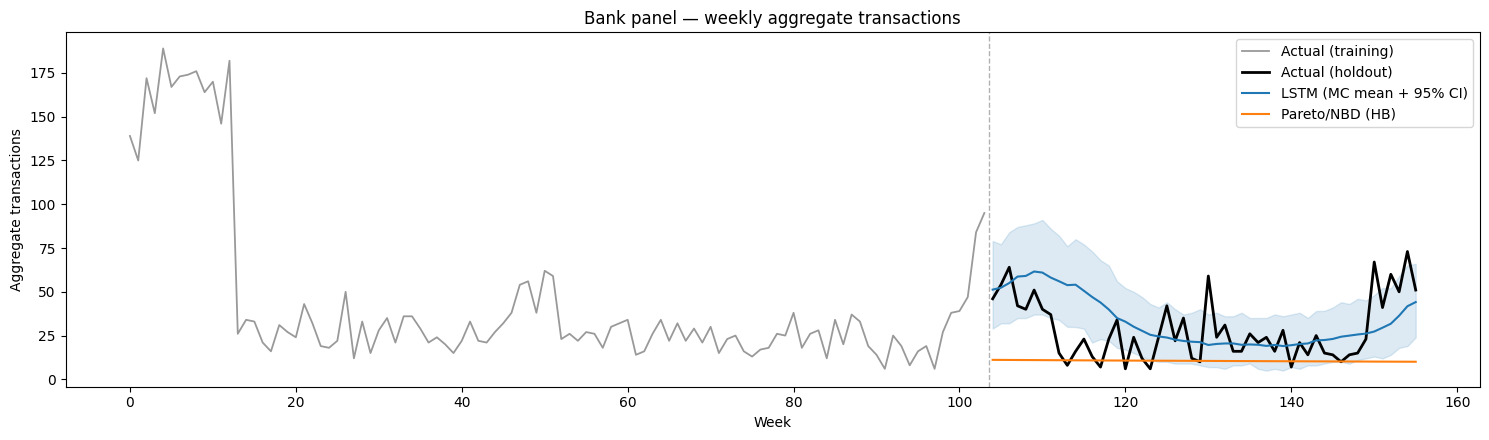

In [14]:
# Aggregate actuals across customers per holdout week.
actuals = forecast["actual"].sum(axis=0)            # (T_HOLD,)

# (Optional) training-window aggregate to show context to the left of the holdout.
# data_full["calibration"] is (N, T_CAL, F); the target column lives at target_idx.
target_idx    = data_full["seq_cols"].index(data_full["target_col"])
train_actuals = data_full["calibration"][..., target_idx].sum(axis=0)   # (T_CAL,)

# Add a trailing 1-axis so weekly_aggregate_predictions takes the (S, N, T, 1)
# branch and draws the 95% MC ribbon.
mc_sims = forecast["simulations"][..., None]        # (S, N, T_HOLD, 1)

fig, ax = plot_weekly_aggregated(
				actuals=actuals,
    data=data_best,
    pareto_paper_benchmark=True,      
				predictions_by_model={"LSTM (MC mean + 95% CI)": mc_sims},
				train_actuals=train_actuals,                    # omit to plot only the holdout
				title="Bank panel — weekly aggregate transactions",
				show_ci=True,
				# save_path="figures/bank_lstm_weekly.png",    # uncomment to save
)


In [15]:
# ---- 11. Side-by-side metrics: LSTM vs the Pareto/NBD benchmarks ---------
# metrics_table scores each model on the same holdout actuals and returns a
# tidy DataFrame (one row per model, columns = RMSE / bias% / MAPE).
#   - forecast["simulations"][..., None]: the (S, N, T_HOLD, 1) shape tells the
#     aggregator this is a Monte Carlo array (it averages the paths internally).
#   - pareto_*_benchmark=True: fit and score the two Pareto/NBD comparators
#     (MLE "lifetimes" + hierarchical-Bayes) on the SAME cohort.
#   - data=data_best: the benchmarks read train_panel / T_HOLD / ids / etc.
#     from it, so they are fit on exactly the customers the LSTM forecast.
tbl = metrics_table(
    forecast["actual"],
    {"LSTM": forecast["simulations"][..., None]},
    pareto_nbd_benchmark=True,
    pareto_paper_benchmark=True,
    data=data_best,
)
print(tbl)


/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


                     rmse  bias_percent  mape_aggregate_style
model                                                        
LSTM             0.376679     17.701772             52.010566
Pareto/NBD       0.375332    -49.427941             57.018737
Pareto/NBD (HB)  0.375823    -62.641629             65.379948


In [16]:
# ---- 12. Aggregate-total sanity check -----------------------------------
# Compare the TOTAL transactions over the whole holdout (summed across all
# customers and weeks) for each model against the truth. A fast gut-check on
# overall level/bias that complements the per-week metrics above.
# _pareto_from_data is the internal benchmark fitter metrics_table uses; we call
# it directly here just to get each Pareto variant's total.
import numpy as np
from panelclv.evaluation.plot_utils import _pareto_from_data
A   = forecast["actual"].sum()                     # total actual holdout tx
L   = forecast["simulations"].mean(0).sum()        # LSTM total (mean over paths)
P   = _pareto_from_data(data_best, "mle").sum()    # Pareto MLE total
H   = _pareto_from_data(data_best, "paper").sum()  # Pareto HB total
print(f"actual={A:.0f}  LSTM={L:.0f}  Pareto={P:.0f}  HB={H:.0f}")
# Context: average transactions per week in each window. NOTE [...,0] is the
# target channel only because Transactions is seq_cols[0] here (target_idx==0);
# use data_best['target_idx'] if you ever reorder the schema.
print(f"calib total/wk={data_best['calibration'][...,0].sum()/data_best['calibration'].shape[1]:.0f}  "
      f"holdout total/wk={A/forecast['actual'].shape[1]:.0f}")


/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


actual=1467  LSTM=1727  Pareto=658  HB=548
calib total/wk=45  holdout total/wk=28
